In [28]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import os

voll=pd.read_excel('Voll.xlsx')

In [29]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import font_manager
font_path = './times.tff'  # 路径可根据实际文件名调整
my_font = font_manager.FontProperties(fname=font_path)

In [30]:
voll_dict={}
for i in range(len(voll)):
    voll_dict[voll['Country'][i]]=voll['voll'][i]

In [31]:
price_data=pd.read_csv('EU Price.csv',index_col=0)

In [32]:
code_to_country = {
    'AT': 'Austria',
    'BE': 'Belgium',
    'CH': 'Switzerland',
    'CZ': 'Czechia',
    'DE_LU': 'Germany',
    'DK_1': 'Denmark',
    'EE': 'Estonia',
    'ES': 'Spain',
    'FR': 'France',
    'HR': 'Croatia',
    'HU': 'Hungary',
    'IE_SEM': 'Ireland',
    'IT_NORD': 'Italy',
    'LT': 'Lithuania',
    'LV': 'Latvia',
    'NL': 'Netherlands',
    'NO_3': 'Norway',
    'PL': 'Poland',
    'PT': 'Portugal',
    'RO': 'Romania',
    'SE_4': 'Sweden',
    'SI': 'Slovenia',
    'SK': 'Slovakia'
}

In [33]:
name_to_code={'results_Ireland.csv':'Ireland',
 'results_Sweden.csv':'Sweden',
 'results_Germany.csv':'Germany',
 'results_Netherlands.csv':'Netherlands',
 'results_Poland.csv':'Poland',
 'results_Norway.csv':'Norway',
 'results_Croatia.csv':'Croatia',
 'results_Belgium.csv':'Belgium',
 'results_Lithuania.csv':'Lithuania',
 'results_Hungary.csv':'Hungary',
 'results_Slovenia.csv':'Slovenia',
 'results_Switzerland.csv':'Switzerland',
 'results_France.csv':'France',
 'results_Denmark.csv':'Denmark',
 'results_Italy.csv':'Italy',
 'results_Latvia.csv':'Latvia',
 'results_Finland.csv':'Finland',
 'results_Romania.csv':'Romania'}

In [34]:
folder_path = 'Inverse_results_europe'
file_pd={}
model_list=['autoformer','CNN','impactnet','informer','LSTM','nbeats','ANN']
dataframes = {}
for filename in name_to_code.keys():
    file_path = os.path.join(folder_path, filename)
    df = pd.read_csv(file_path)
    dataframes['Actual'] = df['True']
    dataframes['Best_Baseline'] = df['Baseline']
    dataframes['Proposed'] = df['Proposed']
    for model_name in model_list:
        print(model_name)
        file_path = os.path.join(folder_path, filename[:-4]+'_'+model_name+'.csv')
        df = pd.read_csv(file_path)
        dataframes[model_name] = df['Baseline']
    print(filename)
    dataframes['Proposed'] = df['Proposed']
    print(name_to_code[filename])
    pd.DataFrame(dataframes).to_csv('EU_processed/'+name_to_code[filename], index=False)
    

autoformer
CNN
impactnet
informer
LSTM
nbeats
ANN
results_Ireland.csv
Ireland
autoformer
CNN
impactnet
informer
LSTM
nbeats
ANN
results_Sweden.csv
Sweden
autoformer
CNN
impactnet
informer
LSTM
nbeats
ANN
results_Germany.csv
Germany
autoformer
CNN
impactnet
informer
LSTM
nbeats
ANN
results_Netherlands.csv
Netherlands
autoformer
CNN
impactnet
informer
LSTM
nbeats
ANN
results_Poland.csv
Poland
autoformer
CNN
impactnet
informer
LSTM
nbeats
ANN
results_Norway.csv
Norway
autoformer
CNN
impactnet
informer
LSTM
nbeats
ANN
results_Croatia.csv
Croatia
autoformer
CNN
impactnet
informer
LSTM
nbeats
ANN
results_Belgium.csv
Belgium
autoformer
CNN
impactnet
informer
LSTM
nbeats
ANN
results_Lithuania.csv
Lithuania
autoformer
CNN
impactnet
informer
LSTM
nbeats
ANN
results_Hungary.csv
Hungary
autoformer
CNN
impactnet
informer
LSTM
nbeats
ANN
results_Slovenia.csv
Slovenia
autoformer
CNN
impactnet
informer
LSTM
nbeats
ANN
results_Switzerland.csv
Switzerland
autoformer
CNN
impactnet
informer
LSTM
nbeats
AN

In [35]:
price_data['datetime']=price_data.index

In [36]:
EU_price_dict={}
for country in code_to_country.keys():
    country_price_data=price_data[price_data['country']==country]
    country_price_data=country_price_data[country_price_data['datetime']<'2024-02-01']['price']
    if code_to_country[country] in  voll_dict.keys():
        EU_price_dict[code_to_country[country]]=np.average(country_price_data)

In [37]:
folder_path = 'EU_processed'
for filename in os.listdir(folder_path):
    if (filename in voll_dict.keys()):
        print(os.path.join(folder_path, filename))
        data=pd.read_csv(os.path.join(folder_path, filename))

EU_processed/Netherlands
EU_processed/Poland
EU_processed/Croatia
EU_processed/Germany
EU_processed/Belgium
EU_processed/Latvia
EU_processed/Italy
EU_processed/Hungary
EU_processed/Romania
EU_processed/France
EU_processed/Slovenia
EU_processed/Ireland
EU_processed/Sweden
EU_processed/Lithuania
EU_processed/Denmark


In [38]:
import os
import pandas as pd
import numpy as np

folder_path = 'EU_processed'
model_list = ['autoformer', 'CNN', 'impactnet', 'informer', 'LSTM', 'nbeats', 'ANN']

EU_voll_result = {
    'Country': [],
    'Model': [],
    'Voll': [],
    'Deviation_proposed': [],
    'Deviation_baseline': [],
    'Deviation': [],
    'Value': [],
    'Total Cost': [],
    'Ratio': [],
    'Value_baseline': [],
    'Value_proposed': []
}

for filename in os.listdir(folder_path):
    country_code = name_to_code.get(filename, filename)
    if country_code in voll_dict.keys():
        print(os.path.join(folder_path, filename))
        data = pd.read_csv(os.path.join(folder_path, filename))
        if not all(col in data.columns for col in ['Actual', 'Proposed', 'Best_Baseline']):
            print(f"文件 {filename} 缺少必要列！")
            continue

        actual_load = np.array(data['Actual'])
        total_cost = np.sum(actual_load) * EU_price_dict[country_code] 
        #/ 1000
        voll = voll_dict[country_code]

        # Proposed vs Baseline
        proposed_forecasts = np.array(data['Proposed'])
        baseline_forecasts = np.array(data['Best_Baseline'])
        deviation_baseline = actual_load - baseline_forecasts
        deviation_baseline[deviation_baseline < 0] = 0
        deviation_proposed = actual_load - proposed_forecasts
        deviation_proposed[deviation_proposed < 0] = 0
        deviation = deviation_baseline - deviation_proposed
        value = np.sum(deviation) * voll
        ratio = value / total_cost if total_cost != 0 else np.nan

        # EU_voll_result['Country'].append(country_code)
        # EU_voll_result['Model'].append('Proposed_vs_Baseline')
        # EU_voll_result['Voll'].append(voll * 1000)
        # EU_voll_result['Deviation'].append(np.sum(deviation))
        # EU_voll_result['Value'].append(value)
        # EU_voll_result['Total Cost'].append(total_cost)
        # EU_voll_result['Ratio'].append(ratio)
        # EU_voll_result['Deviation_proposed'].append(np.sum(deviation_proposed))
        # EU_voll_result['Deviation_baseline'].append(np.sum(deviation_baseline))

        # Proposed vs each model in model_list
        for model in model_list:
            if model in data.columns:
                model_forecasts = np.array(data[model])
                deviation_model = actual_load - model_forecasts
                deviation_model[deviation_model < 0] = 0
                deviation = deviation_model - deviation_proposed  # deviation_proposed已经算过
                value = np.sum(deviation) * voll
                ratio = value / total_cost if total_cost != 0 else np.nan

                EU_voll_result['Country'].append(country_code)
                EU_voll_result['Model'].append(f'Proposed_vs_{model}')
                EU_voll_result['Voll'].append(voll * 1000)
                EU_voll_result['Deviation'].append(np.sum(deviation))
                EU_voll_result['Value'].append(value)
                EU_voll_result['Total Cost'].append(total_cost)
                EU_voll_result['Ratio'].append(ratio)
                EU_voll_result['Deviation_proposed'].append(np.sum(deviation_proposed))
                EU_voll_result['Deviation_baseline'].append(np.sum(deviation_model))
                EU_voll_result['Value_baseline'].append(np.sum(deviation_model) * voll* 1000)
                EU_voll_result['Value_proposed'].append(np.sum(deviation_proposed) * voll* 1000)
EU_voll_result = pd.DataFrame(EU_voll_result)
EU_voll_result.to_csv('EU_voll_result.csv', index=False)


EU_processed/Netherlands
EU_processed/Poland
EU_processed/Croatia
EU_processed/Germany
EU_processed/Belgium
EU_processed/Latvia
EU_processed/Italy
EU_processed/Hungary
EU_processed/Romania
EU_processed/France
EU_processed/Slovenia
EU_processed/Ireland
EU_processed/Sweden
EU_processed/Lithuania
EU_processed/Denmark


In [39]:
best_baseline_data=EU_voll_result[EU_voll_result['Model']=='Proposed_vs_LSTM']
best_baseline_data

,Country,Model,Voll,Deviation_proposed,Deviation_baseline,Deviation,Value,Total Cost,Ratio,Value_baseline,Value_proposed
4,Netherlands,Proposed_vs_LSTM,15737.0,18601.591928,19071.485280,469.893352,7394.711679,2.130513e+08,0.000035,3.001280e+08,2.927333e+08
11,Poland,Proposed_vs_LSTM,12125.0,25018.635767,28280.444901,3261.809134,39549.435752,3.725895e+08,0.000106,3.429004e+08,3.033510e+08
18,Croatia,Proposed_vs_LSTM,5788.0,6067.804957,13265.384291,7197.579334,41659.589188,4.020594e+07,0.001036,7.678004e+07,3.512046e+07
25,Germany,Proposed_vs_LSTM,12610.0,67179.655286,106120.442744,38940.787458,491043.329845,9.831209e+08,0.000499,1.338179e+09,8.471355e+08
32,Belgium,Proposed_vs_LSTM,13455.0,15721.947909,27240.229968,11518.282060,154978.485113,1.679339e+08,0.000923,3.665173e+08,2.115388e+08
39,Latvia,Proposed_vs_LSTM,6373.0,1208.685948,1301.422533,92.736585,591.010254,2.205846e+07,0.000027,8.293966e+06,7.702956e+06
46,Italy,Proposed_vs_LSTM,16210.0,114337.365784,86119.955227,-28217.410557,-457404.225124,7.426969e+08,-0.000616,1.396004e+09,1.853409e+09
53,Hungary,Proposed_vs_LSTM,7444.0,1423.228160,13806.552553,12383.324393,92181.466784,9.175177e+07,0.001005,1.027760e+08,1.059451e+07
60,Romania,Proposed_vs_LSTM,8880.0,9055.448373,15876.682785,6821.234412,60572.561576,1.244015e+08,0.000487,1.409849e+08,8.041238e+07
67,France,Proposed_vs_LSTM,8193.0,102944.220875,52781.338326,-50162.882549,-410984.496720,1.139394e+09,-0.000361,4.324375e+08,8.434220e+08


In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

EU_voll_result = pd.read_csv('EU_voll_result.csv')

# 按模型聚合所有国家
all_countries_summary = EU_voll_result.groupby('Model').agg({
    'Deviation': 'sum',
    'Value': 'sum',
    'Total Cost': 'sum',
    'Ratio': 'mean',  # Ratio建议用均值
    'Deviation_proposed': 'sum',
    'Deviation_baseline': 'sum',
    'Value_baseline': 'sum',
    'Value_proposed': 'sum'
}).reset_index()

all_countries_summary['Ratio'] = all_countries_summary['Deviation_proposed'] / all_countries_summary['Total Cost']

models = all_countries_summary['Model'].tolist()
models = [i[12:] for i in models]
deviation_baseline = all_countries_summary['Deviation_baseline'].tolist


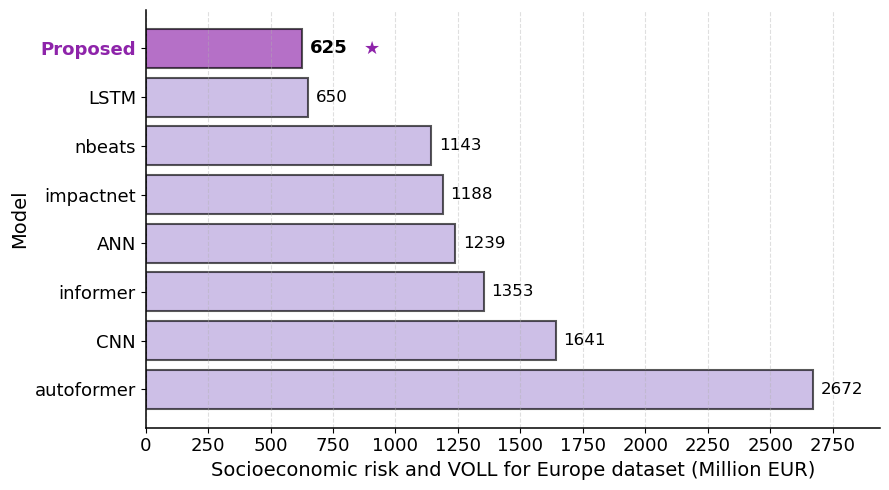

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np 
import matplotlib.ticker as ticker

# 数据读取与处理
EU_voll_result = pd.read_csv('EU_voll_result.csv')

all_countries_summary['Ratio'] = all_countries_summary['Value_proposed'] / all_countries_summary['Total Cost']

models = all_countries_summary['Model'].tolist()
models = [i[12:] for i in models]
deviation_baseline = all_countries_summary['Value_baseline'].tolist()
ratio = all_countries_summary['Ratio'].tolist()

# 只取一个Deviation_proposed值（比如第一个）
proposed_value = all_countries_summary['Value_proposed'].iloc[0]
proposed_ratio = all_countries_summary['Value_proposed'] / all_countries_summary['Total Cost']
proposed_ratio_value = proposed_ratio.iloc[0]

models.append('Proposed')
deviation_baseline.append(proposed_value)
ratio.append(proposed_ratio_value)

# 排序部分：按deviation_baseline从大到小排序
sorted_indices = np.argsort(deviation_baseline)[::-1]
models_sorted = [models[i] for i in sorted_indices]
deviation_baseline_sorted = [deviation_baseline[i] for i in sorted_indices]
ratio_sorted = [ratio[i] for i in sorted_indices]

# 单位换算
deviation_baseline_sorted_million = [v / (1e6*8) for v in deviation_baseline_sorted]


# 紫色系颜色定义
main_purple = '#8e24aa'     # Proposed主紫色
soft_purple = '#b39ddb'     # 其他模型柔和紫灰

colors_sorted = []
for m in models_sorted:
    if m == 'Proposed':
        colors_sorted.append(main_purple)
    else:
        colors_sorted.append(soft_purple)

y = np.arange(len(models_sorted))
height = 0.8

fig, ax = plt.subplots(figsize=(9, 5))

rects = ax.barh(
    y, deviation_baseline_sorted_million, height,
    color=colors_sorted, edgecolor='black', linewidth=1.5, alpha=0.65  # 调低透明度
)

ax.set_ylabel('Model', fontsize=14, color='black')
ax.set_xlabel('Socioeconomic risk and VOLL for Europe dataset (Million EUR)', fontsize=14, color='black')
ax.set_yticks(y)
yticklabels = []
for m in models_sorted:
    if m == 'Proposed':
        yticklabels.append('Proposed')
    else:
        yticklabels.append(m)
ax.set_yticklabels(yticklabels, fontsize=13, color='black')
for label, m in zip(ax.get_yticklabels(), models_sorted):
    if m == 'Proposed':
        label.set_color('#8e24aa')
        label.set_fontweight('bold')

ax.tick_params(axis='x', labelsize=13, colors='black')
ax.grid(axis='x', linestyle='--', alpha=0.4)
ax.xaxis.set_major_locator(ticker.MultipleLocator(250))
ax.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.0f'))
ax.set_xlim(0, max(deviation_baseline_sorted_million)*1.1)

# 柱状标签和Proposed星号标注
for i, rect in enumerate(rects):
    value = deviation_baseline_sorted_million[i]
    x = rect.get_width()
    y_ = rect.get_y() + rect.get_height() / 2
    if models_sorted[i] == 'Proposed':
        ax.text(x + 250/8, y_, f'{value:.0f}', va='center', ha='left', fontsize=13, fontweight='bold', color='black')
        ax.text(x + 250, y_, '★', va='center', ha='left', fontsize=13, fontweight='bold', color='#8e24aa')
    else:
        ax.text(x + 250/8, y_, f'{value:.0f}', va='center', ha='left', fontsize=12, color='black')

# 边框美化
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.1)
ax.spines['bottom'].set_linewidth(1.1)
plt
# ax.set_title('Model Comparison of Avoided Loss', fontsize=16, fontweight='bold', pad=14, color='black')
plt.savefig('sub_figure_c.png', dpi=1000, bbox_inches='tight')
plt.tight_layout()
plt.show()


In [42]:
result_compared_best_baseline = {}

result_compared_best_baseline['country']= EU_voll_result['Country'].unique().tolist()
result_compared_best_baseline['Voll']= EU_voll_result[EU_voll_result['Model']=='Proposed_vs_nbeats']['Voll']
result_compared_best_baseline['Avoided_Loss']= EU_voll_result[EU_voll_result['Model']=='Proposed_vs_nbeats']['Deviation_baseline']- EU_voll_result[EU_voll_result['Model']=='Proposed_vs_nbeats']['Deviation_proposed']
result_compared_best_baseline['Total_Cost']= EU_voll_result[EU_voll_result['Model']=='Proposed_vs_nbeats']['Total Cost']
result_compared_best_baseline ['Value']= EU_voll_result[EU_voll_result['Model']=='Proposed_vs_nbeats']['Value_baseline']-EU_voll_result[EU_voll_result['Model']=='Proposed_vs_nbeats']['Value_proposed']
result_compared_best_baseline['Ratio']= result_compared_best_baseline['Value']/ result_compared_best_baseline['Total_Cost']*100
result_compared_best_baseline['Total_Cost']=result_compared_best_baseline['Total_Cost']/1000000
result_compared_best_baseline['Value']=result_compared_best_baseline['Value']/1000000
# result_compared_best_baseline['Value'] save two point float
result_compared_best_baseline['Value'] = result_compared_best_baseline['Value'].round(2)
result_compared_best_baseline['Total_Cost'] = result_compared_best_baseline['Total_Cost'].round(2)
result_compared_best_baseline['Ratio'] = result_compared_best_baseline['Ratio'].round(2)
result_compared_best_baseline['Avoided_Loss'] = result_compared_best_baseline['Avoided_Loss'].round(2)
pd.DataFrame(result_compared_best_baseline).to_csv('result_compared_best_baseline.csv', index=False)


In [59]:
print(np.sum(result_compared_best_baseline['Total_Cost']))
print(np.sum(result_compared_best_baseline['Value']))
print(np.sum(result_compared_best_baseline['Value'])/8)
print(np.sum(result_compared_best_baseline['Total_Cost'])/8)
print(np.sum(result_compared_best_baseline['Value'])/np.sum(result_compared_best_baseline['Total_Cost']))

4422.249999999999
4142.05
517.75625
552.7812499999999
0.9366385889535872


In [ ]:
pd.DataFrame(result_compared_best_baseline)
pd.DataFrame(result_compared_best_baseline).to_csv('result_compared_to_nbeats.csv', index=False)

,country,Voll,Avoided_Loss,Total_Cost,Value,Ratio
5,Netherlands,15737.0,11875.94,213.05,186.89,87.72
12,Poland,12125.0,53115.36,372.59,644.02,172.85
19,Croatia,5788.0,4301.79,40.21,24.90,61.93
26,Germany,12610.0,43650.68,983.12,550.44,55.99
33,Belgium,13455.0,11083.08,167.93,149.12,88.80
40,Latvia,6373.0,310.01,22.06,1.98,8.96
47,Italy,16210.0,4754.74,742.70,77.07,10.38
54,Hungary,7444.0,12746.56,91.75,94.89,103.42
61,Romania,8880.0,18770.21,124.40,166.68,133.99
68,France,8193.0,218675.82,1139.39,1791.61,157.24


In [60]:
result_compared_best_baseline = {}

result_compared_best_baseline['country']= EU_voll_result['Country'].unique().tolist()
result_compared_best_baseline['Voll']= EU_voll_result[EU_voll_result['Model']=='Proposed_vs_LSTM']['Voll']
result_compared_best_baseline['Avoided_Loss']= EU_voll_result[EU_voll_result['Model']=='Proposed_vs_LSTM']['Deviation_baseline']- EU_voll_result[EU_voll_result['Model']=='Proposed_vs_LSTM']['Deviation_proposed']
result_compared_best_baseline['Total_Cost']= EU_voll_result[EU_voll_result['Model']=='Proposed_vs_LSTM']['Total Cost']
result_compared_best_baseline ['Value']= EU_voll_result[EU_voll_result['Model']=='Proposed_vs_LSTM']['Value_baseline']-EU_voll_result[EU_voll_result['Model']=='Proposed_vs_LSTM']['Value_proposed']
result_compared_best_baseline['Ratio']= result_compared_best_baseline['Value']/ result_compared_best_baseline['Total_Cost']*100
result_compared_best_baseline['Total_Cost']=result_compared_best_baseline['Total_Cost']/1000000
result_compared_best_baseline['Value']=result_compared_best_baseline['Value']/1000000
# result_compared_best_baseline['Value'] save two point float
result_compared_best_baseline['Value'] = result_compared_best_baseline['Value'].round(2)
result_compared_best_baseline['Total_Cost'] = result_compared_best_baseline['Total_Cost'].round(2)
result_compared_best_baseline['Ratio'] = result_compared_best_baseline['Ratio'].round(2)
result_compared_best_baseline['Avoided_Loss'] = result_compared_best_baseline['Avoided_Loss'].round(2)
# pd.DataFrame(result_compared_best_baseline).to_csv('result_compared_best_baseline.csv', index=False)

In [61]:
print(np.sum(result_compared_best_baseline['Total_Cost']))
print(np.sum(result_compared_best_baseline['Value']))
print(np.sum(result_compared_best_baseline['Value'])/8)
print(np.sum(result_compared_best_baseline['Total_Cost'])/8)
print(np.sum(result_compared_best_baseline['Value'])/np.sum(result_compared_best_baseline['Total_Cost']))

4422.249999999999
201.4500000000001
25.181250000000013
552.7812499999999
0.04555373395895758
